In [6]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
wine = load_wine()
X, y = wine.data, wine.target

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [9]:
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [10]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_scaled, y_train)
y_pred_mnb = mnb.predict(X_test_scaled)

In [11]:
gnb_acc = accuracy_score(y_test, y_pred_gnb)
mnb_acc = accuracy_score(y_test, y_pred_mnb)

print(f"Gaussian NB Accuracy    : {gnb_acc*100:.2f}%")
print(f"Multinomial NB Accuracy : {mnb_acc*100:.2f}%")
print(f"\nBetter Model: {'Gaussian NB' if gnb_acc >= mnb_acc else 'Multinomial NB'}")

Gaussian NB Accuracy    : 100.00%
Multinomial NB Accuracy : 97.22%

Better Model: Gaussian NB


In [12]:
print("\nGaussian NB - Classification Report:")
print(classification_report(y_test, y_pred_gnb, target_names=wine.target_names))

print("Multinomial NB - Classification Report:")
print(classification_report(y_test, y_pred_mnb, target_names=wine.target_names))



Gaussian NB - Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        14
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00         8

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36

Multinomial NB - Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      0.93      0.96        14
     class_1       0.93      1.00      0.97        14
     class_2       1.00      1.00      1.00         8

    accuracy                           0.97        36
   macro avg       0.98      0.98      0.98        36
weighted avg       0.97      0.97      0.97        36



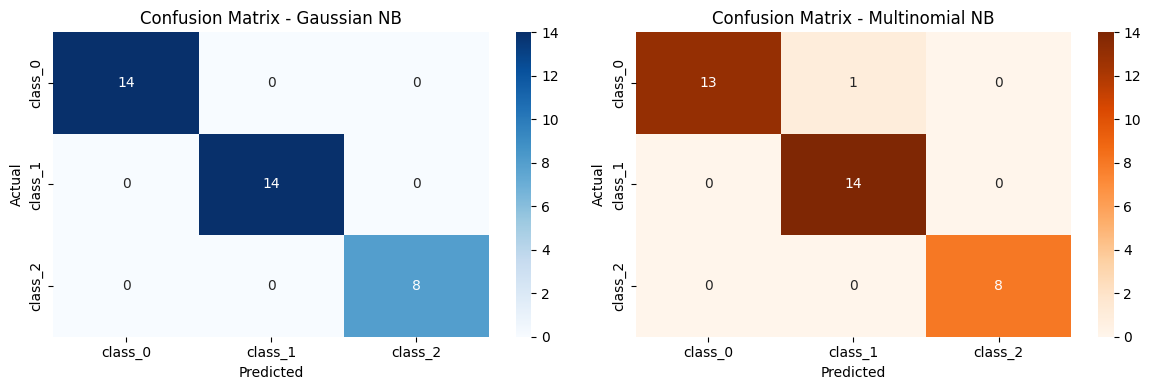

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title, cmap in [
    (axes[0], y_pred_gnb, 'Confusion Matrix - Gaussian NB',    'Blues'),
    (axes[1], y_pred_mnb, 'Confusion Matrix - Multinomial NB', 'Oranges'),
]:
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d',
                cmap=cmap, xticklabels=wine.target_names,
                yticklabels=wine.target_names, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [14]:
print("\nPredictions on test data (first 10 samples):")
print(f"{'#':<4} {'Actual':<12} {'Gaussian NB':<14} {'Multinomial NB'}")
print("-" * 46)
for i in range(10):
    print(f"{i+1:<4} {wine.target_names[y_test[i]]:<12} "
          f"{wine.target_names[y_pred_gnb[i]]:<14} "
          f"{wine.target_names[y_pred_mnb[i]]}")


Predictions on test data (first 10 samples):
#    Actual       Gaussian NB    Multinomial NB
----------------------------------------------
1    class_0      class_0        class_0
2    class_0      class_0        class_0
3    class_2      class_2        class_2
4    class_0      class_0        class_0
5    class_1      class_1        class_1
6    class_0      class_0        class_0
7    class_1      class_1        class_1
8    class_2      class_2        class_2
9    class_1      class_1        class_1
10   class_2      class_2        class_2
